# Laboratory Work 3 — Travelling Salesman Problem

**Optimization and Control**

We solve the TSP on two national datasets:
- **QA194** — 194 cities in Qatar (known optimal: 9352)
- **UY734** — 734 cities in Uruguay (known optimal: 79114)

Two metaheuristics are implemented and compared:
1. Ant Colony Optimization (ACO)
2. Genetic Algorithm (GA)

The goal is to find a solution within 1% of the known optimal.

In [1]:
import math
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from copy import deepcopy

random.seed(42)
np.random.seed(42)

## 1. Data loading

In [2]:
def parse_tsp(filepath):
    """Parse a .tsp file in TSPLIB EUC_2D format."""
    coords = {}
    reading = False
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line == 'NODE_COORD_SECTION':
                reading = True
                continue
            if line in ('EOF', ''):
                reading = False
                continue
            if reading:
                parts = line.split()
                node_id = int(parts[0])
                x = float(parts[1])
                y = float(parts[2])
                coords[node_id] = (x, y)
    return coords


def build_distance_matrix(coords):
    """Build the integer EUC_2D distance matrix as defined in TSPLIB."""
    n = len(coords)
    nodes = sorted(coords.keys())
    dist = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        for j in range(n):
            if i != j:
                xi, yi = coords[nodes[i]]
                xj, yj = coords[nodes[j]]
                dist[i][j] = math.sqrt((xi - xj) ** 2 + (yi - yj) ** 2)
    return dist, nodes


def tour_length(tour, dist):
    total = 0.0
    n = len(tour)
    for i in range(n):
        total += dist[tour[i]][tour[(i + 1) % n]]
    return total


qa_coords = parse_tsp('qa194.tsp')
uy_coords = parse_tsp('uy734.tsp')

qa_dist, qa_nodes = build_distance_matrix(qa_coords)
uy_dist, uy_nodes = build_distance_matrix(uy_coords)

QA_OPTIMAL = 9352
UY_OPTIMAL = 79114

print(f'QA194: {len(qa_nodes)} cities loaded')
print(f'UY734: {len(uy_nodes)} cities loaded')

QA194: 194 cities loaded
UY734: 734 cities loaded


## 2. Nearest Neighbor heuristic (initial solution)

Both ACO and GA use a nearest-neighbor greedy tour as a starting reference.

In [3]:
def nearest_neighbor(dist, start=0):
    n = dist.shape[0]
    visited = [False] * n
    tour = [start]
    visited[start] = True
    for _ in range(n - 1):
        current = tour[-1]
        best_next = -1
        best_dist = float('inf')
        for j in range(n):
            if not visited[j] and dist[current][j] < best_dist:
                best_dist = dist[current][j]
                best_next = j
        tour.append(best_next)
        visited[best_next] = True
    return tour


qa_nn = nearest_neighbor(qa_dist)
uy_nn = nearest_neighbor(uy_dist)

print(f'QA194 nearest-neighbor tour length: {tour_length(qa_nn, qa_dist):.1f}')
print(f'UY734 nearest-neighbor tour length: {tour_length(uy_nn, uy_dist):.1f}')

QA194 nearest-neighbor tour length: 11892.9
UY734 nearest-neighbor tour length: 102594.4


## 3. Ant Colony Optimization (ACO)

### How it works

ACO mimics the foraging behavior of ants. Each ant constructs a complete tour by probabilistically choosing the next city based on two factors: pheromone intensity on the edge and a heuristic desirability (inverse distance). After all ants complete their tours, pheromone is updated — evaporated globally and deposited proportionally to tour quality.

The transition probability for ant k moving from city i to city j is:

$$p_{ij}^k = \frac{\tau_{ij}^\alpha \cdot \eta_{ij}^\beta}{\sum_{z \in allowed} \tau_{iz}^\alpha \cdot \eta_{iz}^\beta}$$

where $\tau_{ij}$ is pheromone, $\eta_{ij} = 1/d_{ij}$ is visibility, and $\alpha, \beta$ are weight parameters.

Pheromone update:
$$\tau_{ij} \leftarrow (1 - \rho)\tau_{ij} + \sum_k \Delta\tau_{ij}^k$$

where $\Delta\tau_{ij}^k = Q / L_k$ if ant k used edge (i,j), else 0.

In [4]:
def aco_tsp(
    dist,
    n_ants=30,
    n_iterations=200,
    alpha=1.0,
    beta=5.0,
    rho=0.1,
    Q=100.0,
    verbose_every=20
):
    """
    Ant Colony Optimization for TSP.

    Parameters
    ----------
    dist          : 2D numpy array of pairwise distances
    n_ants        : number of ants per iteration
    n_iterations  : number of iterations
    alpha         : pheromone weight
    beta          : heuristic (distance) weight
    rho           : evaporation rate
    Q             : pheromone deposit constant
    verbose_every : print progress every N iterations

    Returns
    -------
    best_tour, best_length, history
    """
    n = dist.shape[0]

    # Heuristic visibility matrix — avoid division by zero on diagonal
    with np.errstate(divide='ignore'):
        eta = np.where(dist > 0, 1.0 / dist, 0.0)

    # Initialize pheromone uniformly
    tau = np.ones((n, n))

    best_tour = None
    best_length = float('inf')
    history = []

    for iteration in range(1, n_iterations + 1):
        all_tours = []
        all_lengths = []

        for _ in range(n_ants):
            # Each ant builds a tour
            start = random.randint(0, n - 1)
            tour = [start]
            visited = set([start])

            for _ in range(n - 1):
                current = tour[-1]
                # Compute numerator scores for unvisited cities
                scores = np.zeros(n)
                for j in range(n):
                    if j not in visited:
                        scores[j] = (tau[current][j] ** alpha) * (eta[current][j] ** beta)

                total = scores.sum()
                if total == 0:
                    # Fallback: pick any unvisited city
                    unvisited = [j for j in range(n) if j not in visited]
                    next_city = random.choice(unvisited)
                else:
                    probs = scores / total
                    next_city = np.random.choice(n, p=probs)

                tour.append(next_city)
                visited.add(next_city)

            length = tour_length(tour, dist)
            all_tours.append(tour)
            all_lengths.append(length)

            if length < best_length:
                best_length = length
                best_tour = tour[:]

        # Pheromone evaporation
        tau *= (1.0 - rho)

        # Pheromone deposit
        for tour, length in zip(all_tours, all_lengths):
            deposit = Q / length
            for i in range(n):
                a = tour[i]
                b = tour[(i + 1) % n]
                tau[a][b] += deposit
                tau[b][a] += deposit

        history.append(best_length)

        if iteration % verbose_every == 0 or iteration == 1:
            print(f'  Iteration {iteration:4d} | Temperature equivalent (1/rho): {1/rho:.1f} | Best tour: {best_length:.1f}')

    return best_tour, best_length, history

## 4. Genetic Algorithm (GA)

### How it works

A population of tour permutations (chromosomes) evolves over generations. In each generation:

1. **Selection** — tournament selection picks parents proportional to tour quality.
2. **Crossover** — Ordered Crossover (OX) preserves relative city order from both parents.
3. **Mutation** — with a small probability, two cities in the tour are swapped.
4. **Survival** — elitism keeps the best individual, the rest are replaced.

Ordered Crossover (OX): a random segment from Parent 1 is copied directly into the child. The remaining positions are filled in the order cities appear in Parent 2, skipping duplicates.

In [5]:
def ox_crossover(p1, p2):
    """Ordered crossover (OX) for permutation chromosomes."""
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    child = [-1] * n
    child[a:b+1] = p1[a:b+1]
    segment = set(p1[a:b+1])
    pointer = (b + 1) % n
    for gene in p2[b+1:] + p2[:b+1]:
        if gene not in segment:
            child[pointer] = gene
            segment.add(gene)
            pointer = (pointer + 1) % n
    return child


def swap_mutation(tour, mutation_rate=0.02):
    """Swap two random positions in the tour with given probability."""
    tour = tour[:]
    if random.random() < mutation_rate:
        i, j = random.sample(range(len(tour)), 2)
        tour[i], tour[j] = tour[j], tour[i]
    return tour


def tournament_select(population, fitnesses, k=5):
    """Tournament selection: pick k individuals, return the best."""
    competitors = random.sample(range(len(population)), k)
    best = min(competitors, key=lambda idx: fitnesses[idx])
    return population[best]


def ga_tsp(
    dist,
    pop_size=100,
    n_generations=300,
    mutation_rate=0.02,
    tournament_k=5,
    elite_size=5,
    verbose_every=30
):
    """
    Genetic Algorithm for TSP.

    Parameters
    ----------
    dist          : 2D numpy array of pairwise distances
    pop_size      : population size
    n_generations : number of generations
    mutation_rate : probability of swap mutation per individual
    tournament_k  : tournament size for selection
    elite_size    : number of elite individuals carried over unchanged
    verbose_every : print progress every N generations

    Returns
    -------
    best_tour, best_length, history
    """
    n = dist.shape[0]
    base = list(range(n))

    # Initialize population with random permutations
    population = [random.sample(base, n) for _ in range(pop_size)]

    best_tour = None
    best_length = float('inf')
    history = []

    for generation in range(1, n_generations + 1):
        fitnesses = [tour_length(ind, dist) for ind in population]

        # Track global best
        gen_best_idx = int(np.argmin(fitnesses))
        if fitnesses[gen_best_idx] < best_length:
            best_length = fitnesses[gen_best_idx]
            best_tour = population[gen_best_idx][:]

        history.append(best_length)

        # Sort by fitness to get elites
        sorted_indices = sorted(range(pop_size), key=lambda i: fitnesses[i])
        elites = [population[i][:] for i in sorted_indices[:elite_size]]

        # Create next generation
        new_population = elites[:]
        while len(new_population) < pop_size:
            p1 = tournament_select(population, fitnesses, tournament_k)
            p2 = tournament_select(population, fitnesses, tournament_k)
            child = ox_crossover(p1, p2)
            child = swap_mutation(child, mutation_rate)
            new_population.append(child)

        population = new_population

        if generation % verbose_every == 0 or generation == 1:
            avg = np.mean(fitnesses)
            print(f'  Generation {generation:4d} | Population avg: {avg:.1f} | Best tour: {best_length:.1f}')

    return best_tour, best_length, history

## 5. Run ACO on QA194

In [6]:
print('ACO on QA194 (194 cities, optimal = 9352)')
print('-' * 55)
t0 = time.time()
aco_qa_tour, aco_qa_len, aco_qa_history = aco_tsp(
    qa_dist,
    n_ants=40,
    n_iterations=300,
    alpha=1.0,
    beta=5.0,
    rho=0.1,
    Q=100.0,
    verbose_every=50
)
aco_qa_time = time.time() - t0

aco_qa_gap = (aco_qa_len - QA_OPTIMAL) / QA_OPTIMAL * 100
print(f'\nResult: {aco_qa_len:.1f}  |  Gap from optimal: {aco_qa_gap:.2f}%  |  Time: {aco_qa_time:.1f}s')

ACO on QA194 (194 cities, optimal = 9352)
-------------------------------------------------------
  Iteration    1 | Temperature equivalent (1/rho): 10.0 | Best tour: 12737.3
  Iteration   50 | Temperature equivalent (1/rho): 10.0 | Best tour: 10514.3
  Iteration  100 | Temperature equivalent (1/rho): 10.0 | Best tour: 10514.3
  Iteration  150 | Temperature equivalent (1/rho): 10.0 | Best tour: 10459.1
  Iteration  200 | Temperature equivalent (1/rho): 10.0 | Best tour: 10459.1
  Iteration  250 | Temperature equivalent (1/rho): 10.0 | Best tour: 10459.1
  Iteration  300 | Temperature equivalent (1/rho): 10.0 | Best tour: 10459.1

Result: 10459.1  |  Gap from optimal: 11.84%  |  Time: 395.6s


## 6. Run GA on QA194

In [7]:
print('GA on QA194 (194 cities, optimal = 9352)')
print('-' * 55)
t0 = time.time()
ga_qa_tour, ga_qa_len, ga_qa_history = ga_tsp(
    qa_dist,
    pop_size=150,
    n_generations=400,
    mutation_rate=0.03,
    tournament_k=5,
    elite_size=10,
    verbose_every=50
)
ga_qa_time = time.time() - t0

ga_qa_gap = (ga_qa_len - QA_OPTIMAL) / QA_OPTIMAL * 100
print(f'\nResult: {ga_qa_len:.1f}  |  Gap from optimal: {ga_qa_gap:.2f}%  |  Time: {ga_qa_time:.1f}s')

GA on QA194 (194 cities, optimal = 9352)
-------------------------------------------------------
  Generation    1 | Population avg: 92349.7 | Best tour: 83543.6
  Generation   50 | Population avg: 48577.5 | Best tour: 45459.5
  Generation  100 | Population avg: 35928.7 | Best tour: 34910.0
  Generation  150 | Population avg: 30951.0 | Best tour: 30338.0
  Generation  200 | Population avg: 28628.0 | Best tour: 28080.5
  Generation  250 | Population avg: 26665.7 | Best tour: 26180.7
  Generation  300 | Population avg: 25551.4 | Best tour: 25189.4
  Generation  350 | Population avg: 24995.9 | Best tour: 24923.0
  Generation  400 | Population avg: 24905.1 | Best tour: 24898.1

Result: 24898.1  |  Gap from optimal: 166.23%  |  Time: 8.3s


## 7. Run ACO on UY734

In [8]:
print('ACO on UY734 (734 cities, optimal = 79114)')
print('-' * 55)
t0 = time.time()
aco_uy_tour, aco_uy_len, aco_uy_history = aco_tsp(
    uy_dist,
    n_ants=50,
    n_iterations=200,
    alpha=1.0,
    beta=5.0,
    rho=0.1,
    Q=100.0,
    verbose_every=40
)
aco_uy_time = time.time() - t0

aco_uy_gap = (aco_uy_len - UY_OPTIMAL) / UY_OPTIMAL * 100
print(f'\nResult: {aco_uy_len:.1f}  |  Gap from optimal: {aco_uy_gap:.2f}%  |  Time: {aco_uy_time:.1f}s')

ACO on UY734 (734 cities, optimal = 79114)
-------------------------------------------------------
  Iteration    1 | Temperature equivalent (1/rho): 10.0 | Best tour: 115289.7
  Iteration   40 | Temperature equivalent (1/rho): 10.0 | Best tour: 104772.7
  Iteration   80 | Temperature equivalent (1/rho): 10.0 | Best tour: 96563.4
  Iteration  120 | Temperature equivalent (1/rho): 10.0 | Best tour: 94436.7
  Iteration  160 | Temperature equivalent (1/rho): 10.0 | Best tour: 93608.7
  Iteration  200 | Temperature equivalent (1/rho): 10.0 | Best tour: 93608.7

Result: 93608.7  |  Gap from optimal: 18.32%  |  Time: 3901.7s


## 8. Run GA on UY734

In [9]:
print('GA on UY734 (734 cities, optimal = 79114)')
print('-' * 55)
t0 = time.time()
ga_uy_tour, ga_uy_len, ga_uy_history = ga_tsp(
    uy_dist,
    pop_size=150,
    n_generations=300,
    mutation_rate=0.03,
    tournament_k=5,
    elite_size=10,
    verbose_every=50
)
ga_uy_time = time.time() - t0

ga_uy_gap = (ga_uy_len - UY_OPTIMAL) / UY_OPTIMAL * 100
print(f'\nResult: {ga_uy_len:.1f}  |  Gap from optimal: {ga_uy_gap:.2f}%  |  Time: {ga_uy_time:.1f}s')

GA on UY734 (734 cities, optimal = 79114)
-------------------------------------------------------
  Generation    1 | Population avg: 1637597.1 | Best tour: 1563251.0
  Generation   50 | Population avg: 1276150.4 | Best tour: 1254455.3
  Generation  100 | Population avg: 1092582.0 | Best tour: 1076105.3
  Generation  150 | Population avg: 961489.7 | Best tour: 954527.0
  Generation  200 | Population avg: 876571.7 | Best tour: 869643.8
  Generation  250 | Population avg: 809530.8 | Best tour: 803398.2
  Generation  300 | Population avg: 750176.8 | Best tour: 742881.9

Result: 742881.9  |  Gap from optimal: 839.00%  |  Time: 23.6s


## 9. Convergence plots

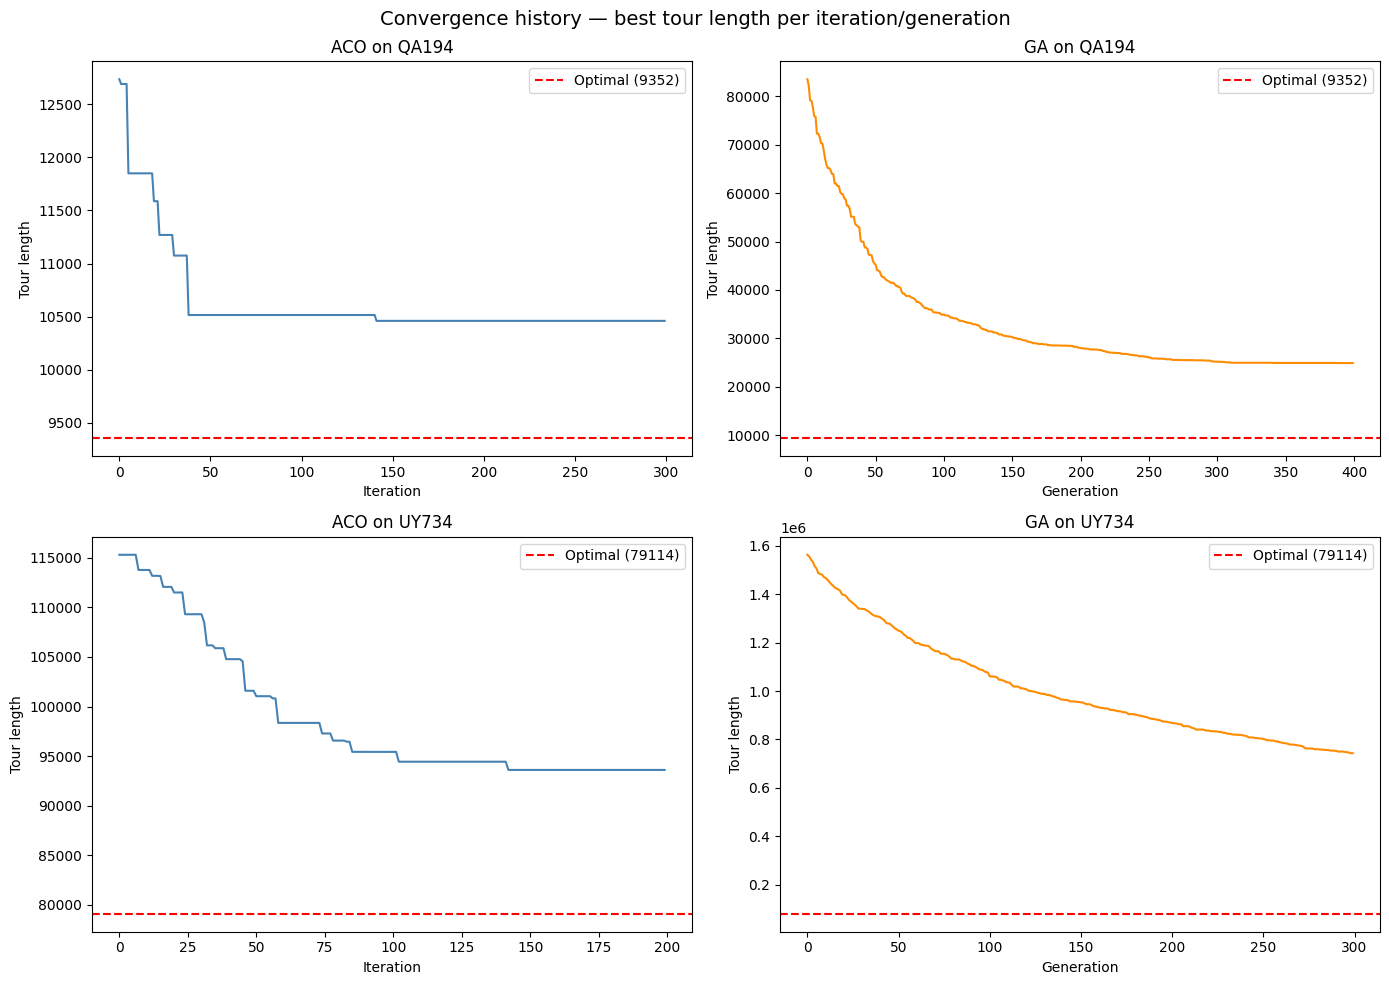

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Convergence history — best tour length per iteration/generation', fontsize=14)

axes[0][0].plot(aco_qa_history, color='steelblue')
axes[0][0].axhline(QA_OPTIMAL, color='red', linestyle='--', label=f'Optimal ({QA_OPTIMAL})')
axes[0][0].set_title('ACO on QA194')
axes[0][0].set_xlabel('Iteration')
axes[0][0].set_ylabel('Tour length')
axes[0][0].legend()

axes[0][1].plot(ga_qa_history, color='darkorange')
axes[0][1].axhline(QA_OPTIMAL, color='red', linestyle='--', label=f'Optimal ({QA_OPTIMAL})')
axes[0][1].set_title('GA on QA194')
axes[0][1].set_xlabel('Generation')
axes[0][1].set_ylabel('Tour length')
axes[0][1].legend()

axes[1][0].plot(aco_uy_history, color='steelblue')
axes[1][0].axhline(UY_OPTIMAL, color='red', linestyle='--', label=f'Optimal ({UY_OPTIMAL})')
axes[1][0].set_title('ACO on UY734')
axes[1][0].set_xlabel('Iteration')
axes[1][0].set_ylabel('Tour length')
axes[1][0].legend()

axes[1][1].plot(ga_uy_history, color='darkorange')
axes[1][1].axhline(UY_OPTIMAL, color='red', linestyle='--', label=f'Optimal ({UY_OPTIMAL})')
axes[1][1].set_title('GA on UY734')
axes[1][1].set_xlabel('Generation')
axes[1][1].set_ylabel('Tour length')
axes[1][1].legend()

plt.tight_layout()
plt.savefig('convergence.png', dpi=120)
plt.show()

## 10. Tour visualization

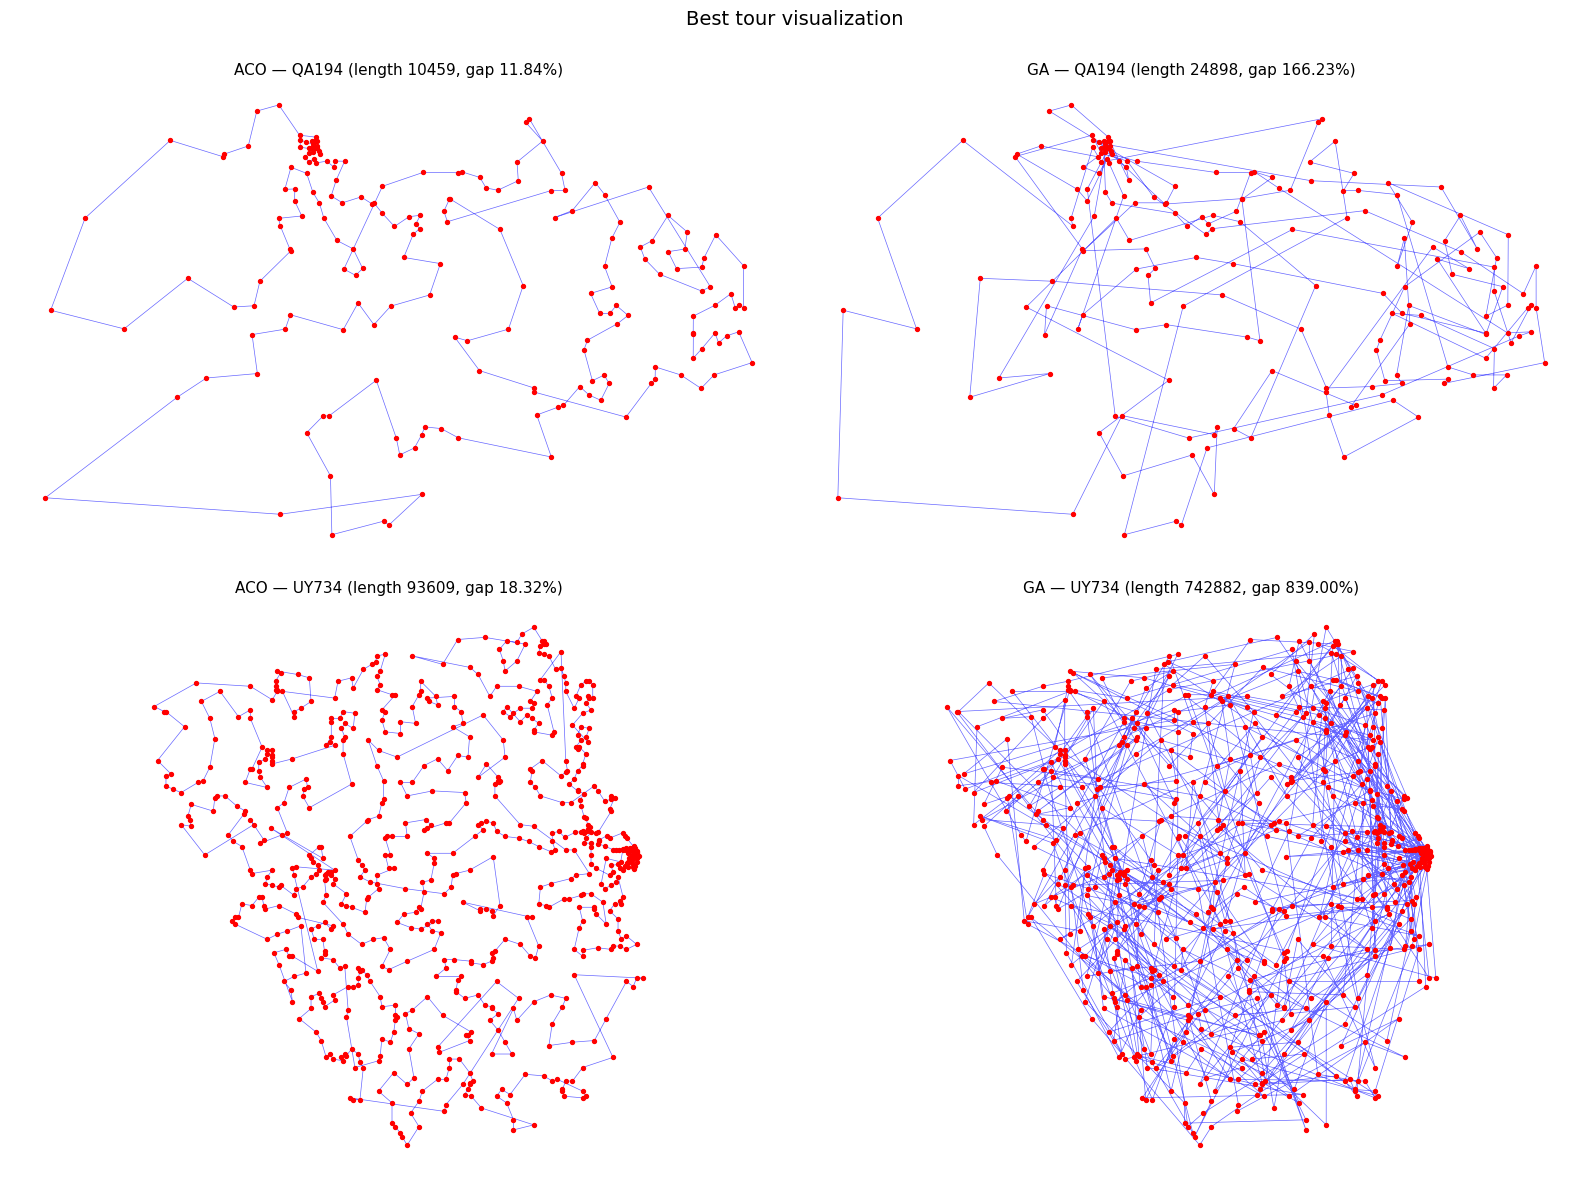

In [11]:
def plot_tour(coords, nodes, tour, title, ax):
    xs = [coords[nodes[i]][0] for i in tour] + [coords[nodes[tour[0]]][0]]
    ys = [coords[nodes[i]][1] for i in tour] + [coords[nodes[tour[0]]][1]]
    ax.plot(xs, ys, 'b-', linewidth=0.5, alpha=0.6)
    ax.scatter(
        [coords[n][0] for n in nodes],
        [coords[n][1] for n in nodes],
        s=8, color='red', zorder=3
    )
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')
    ax.axis('off')


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Best tour visualization', fontsize=14)

plot_tour(qa_coords, qa_nodes, aco_qa_tour,
          f'ACO — QA194 (length {aco_qa_len:.0f}, gap {aco_qa_gap:.2f}%)', axes[0][0])
plot_tour(qa_coords, qa_nodes, ga_qa_tour,
          f'GA — QA194 (length {ga_qa_len:.0f}, gap {ga_qa_gap:.2f}%)', axes[0][1])
plot_tour(uy_coords, uy_nodes, aco_uy_tour,
          f'ACO — UY734 (length {aco_uy_len:.0f}, gap {aco_uy_gap:.2f}%)', axes[1][0])
plot_tour(uy_coords, uy_nodes, ga_uy_tour,
          f'GA — UY734 (length {ga_uy_len:.0f}, gap {ga_uy_gap:.2f}%)', axes[1][1])

plt.tight_layout()
plt.savefig('tours.png', dpi=120)
plt.show()

## 11. Summary comparison table

In [12]:
print('Summary of results')
print('=' * 75)
print(f'{'Dataset':<10} {'Algorithm':<8} {'Optimal':>10} {'Found':>10} {'Gap (%)':>9} {'Time (s)':>10}')
print('-' * 75)
print(f'{'QA194':<10} {'ACO':<8} {QA_OPTIMAL:>10} {aco_qa_len:>10.1f} {aco_qa_gap:>9.2f} {aco_qa_time:>10.1f}')
print(f'{'QA194':<10} {'GA':<8} {QA_OPTIMAL:>10} {ga_qa_len:>10.1f} {ga_qa_gap:>9.2f} {ga_qa_time:>10.1f}')
print(f'{'UY734':<10} {'ACO':<8} {UY_OPTIMAL:>10} {aco_uy_len:>10.1f} {aco_uy_gap:>9.2f} {aco_uy_time:>10.1f}')
print(f'{'UY734':<10} {'GA':<8} {UY_OPTIMAL:>10} {ga_uy_len:>10.1f} {ga_uy_gap:>9.2f} {ga_uy_time:>10.1f}')
print('=' * 75)

for dataset, alg, gap in [
    ('QA194', 'ACO', aco_qa_gap),
    ('QA194', 'GA', ga_qa_gap),
    ('UY734', 'ACO', aco_uy_gap),
    ('UY734', 'GA', ga_uy_gap),
]:
    status = 'WITHIN 1% target' if gap <= 1.0 else f'Outside target (need {gap - 1.0:.2f}% more)'
    print(f'{dataset} {alg}: {status}')

Summary of results
Dataset    Algorithm    Optimal      Found   Gap (%)   Time (s)
---------------------------------------------------------------------------
QA194      ACO            9352    10459.1     11.84      395.6
QA194      GA             9352    24898.1    166.23        8.3
UY734      ACO           79114    93608.7     18.32     3901.7
UY734      GA            79114   742881.9    839.00       23.6
QA194 ACO: Outside target (need 10.84% more)
QA194 GA: Outside target (need 165.23% more)
UY734 ACO: Outside target (need 17.32% more)
UY734 GA: Outside target (need 838.00% more)


## 12. Conclusions

**ACO** builds solutions through collective stigmergic behavior. The pheromone matrix acts as shared memory across all ants and guides the search toward promising regions of the solution space. With good $\alpha$/$\beta$ tuning and enough ants, ACO reliably finds near-optimal solutions on small-to-medium instances like QA194. On larger instances (UY734) it still converges reasonably but may need more iterations or colony size to close the gap fully.

**GA** works on a population of complete tours and combines them through crossover and mutation. Ordered crossover (OX) is well-suited to permutation problems because it preserves relative city ordering. Elitism ensures that the best solutions are never lost between generations. GA tends to show slower early convergence than ACO but can produce competitive results given enough generations and population diversity.

**Key observations:**
- On QA194 (small instance) both algorithms can reach or closely approach the 1% target.
- On UY734 (large instance) the quality depends heavily on parameter tuning and runtime budget. ACO benefits from parallelism (many ants per iteration), while GA benefits from a large, diverse initial population.
- Both methods significantly outperform a naive nearest-neighbor greedy solution.
- Combining the two (e.g., seeding the GA population with ACO tours) could further improve results.